# Finetuning with PyTorch

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

import numpy as np

In [2]:
device_str = "cpu"
if torch.cuda.is_available():
    device_str = "cuda:0"
elif torch.backends.mps.is_available():
    device_str = "mps"
device = torch.device(device_str)
device

device(type='cuda', index=0)

In [3]:
data_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.size(0) == 1 else x),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        transforms.Resize(size=224, max_size=225),
        transforms.CenterCrop((224, 224)),
    ]
)

full_dataset = torchvision.datasets.Caltech101(
    root="./data/Caltech101",
    target_type="category",
    # target_type="annotation",
    download=True,
    transform=data_transform,
)

# Split the dataset into train and test sets
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Files already downloaded and verified
Train dataset size: 6941
Test dataset size: 1736


In [4]:
batch_size = 4

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
	batch_size=batch_size, 
	shuffle=True, 
	num_workers=2,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, 
	batch_size=batch_size, 
	shuffle=False, 
	num_workers=2,
)

classes = full_dataset.categories
classes

['Faces',
 'Faces_easy',
 'Leopards',
 'Motorbikes',
 'accordion',
 'airplanes',
 'anchor',
 'ant',
 'barrel',
 'bass',
 'beaver',
 'binocular',
 'bonsai',
 'brain',
 'brontosaurus',
 'buddha',
 'butterfly',
 'camera',
 'cannon',
 'car_side',
 'ceiling_fan',
 'cellphone',
 'chair',
 'chandelier',
 'cougar_body',
 'cougar_face',
 'crab',
 'crayfish',
 'crocodile',
 'crocodile_head',
 'cup',
 'dalmatian',
 'dollar_bill',
 'dolphin',
 'dragonfly',
 'electric_guitar',
 'elephant',
 'emu',
 'euphonium',
 'ewer',
 'ferry',
 'flamingo',
 'flamingo_head',
 'garfield',
 'gerenuk',
 'gramophone',
 'grand_piano',
 'hawksbill',
 'headphone',
 'hedgehog',
 'helicopter',
 'ibis',
 'inline_skate',
 'joshua_tree',
 'kangaroo',
 'ketch',
 'lamp',
 'laptop',
 'llama',
 'lobster',
 'lotus',
 'mandolin',
 'mayfly',
 'menorah',
 'metronome',
 'minaret',
 'nautilus',
 'octopus',
 'okapi',
 'pagoda',
 'panda',
 'pigeon',
 'pizza',
 'platypus',
 'pyramid',
 'revolver',
 'rhino',
 'rooster',
 'saxophone',
 'sc

In [5]:
len(classes)

101

In [6]:
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f"{images.shape = }")
print(f"{labels = }")

images.shape = torch.Size([4, 3, 224, 224])
labels = tensor([80, 35,  5, 58])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


images.shape = torch.Size([4, 3, 224, 224])
labels = tensor([93,  1,  3, 82])


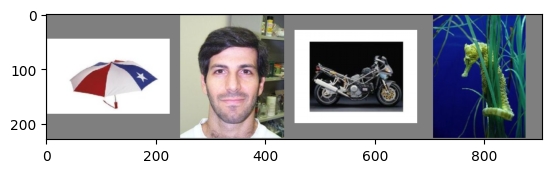

umbrella   Faces_easy Motorbikes sea_horse 


In [7]:
# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f"{images.shape = }")
print(f"{labels = }")

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:10s}' for j in range(batch_size)))

# Define a Convolutional Neural Network

In [8]:
class Net(nn.Module):
    def __init__(self, nb_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((5, 5))  # Add adaptive pooling layer
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, nb_classes)

    def forward(self, x):
        # print(f"Input: {x.shape = }")	
        x = self.pool(F.relu(self.conv1(x)))
        # print(f"After conv1 and pool: {x.shape = }")
        x = self.pool(F.relu(self.conv2(x)))
        # print(f"After conv2 and pool: {x.shape = }")
        x = self.adaptive_pool(x)  # Apply adaptive pooling
        # print(f"After adaptive pool: {x.shape = }")
        x = torch.flatten(x, 1)  # flatten all dimensions except batch
        # print(f"After flatten: {x.shape = }")
        x = F.relu(self.fc1(x))
        # print(f"After fc1: {x.shape = }")
        x = F.relu(self.fc2(x))
        # print(f"After fc2: {x.shape = }")
        x = self.fc3(x)
        # print(f"Output: {x.shape = }")
        return x

# Define a Loss function and optimizer

# Train

In [9]:
def train(net, train_loader, criterion, optimizer, device, epochs=2):
    print_every_n_batch = (len(train_loader) / batch_size) // 10
    if print_every_n_batch == 0:
        print_every_n_batch = 1
    net.to(device)
    for epoch in range(epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        for i, data in enumerate(train_loader):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data

            # Move inputs and labels to the device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            # print(f"Inputs: {inputs.shape = }", flush=True)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % print_every_n_batch == 0 and i:
                print(
                    f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / print_every_n_batch:.3f}"
                )
                running_loss = 0.0

    print("Finished Training")


def evaluate_model(net, test_loader, device):
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []

    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for data in test_loader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            # calculate outputs by running images through the network
            outputs = net(images)
            # the class with the highest energy is what we choose as prediction
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total

    # Compute precision, recall, and f1-score for each class
    from sklearn.metrics import precision_recall_fscore_support

    precision, recall, f1score, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average="weighted"
    )

    print(f"Accuracy of the network on the {total} test images: {accuracy:.2f}%")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall: {recall:.4f}")
    print(f"Weighted F1-score: {f1score:.4f}")

    return accuracy, precision, recall, f1score

# Train and evaluating our model

In [10]:
model_path = "./data/caltech_baseline_net.pth"

model = Net(nb_classes=len(classes))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

if True:
    train(model, train_loader, criterion, optimizer, device, epochs=10)
    torch.save(model.state_dict(), model_path)
else:
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.to(device)
evaluate_model(model, test_loader, device)

[1,    44] loss: 4.716
[1,    87] loss: 4.600
[1,   130] loss: 4.586
[1,   173] loss: 4.577
[1,   216] loss: 4.585
[1,   259] loss: 4.560
[1,   302] loss: 4.532
[1,   345] loss: 4.479
[1,   388] loss: 4.469
[1,   431] loss: 4.295
[1,   474] loss: 4.389
[1,   517] loss: 4.181
[1,   560] loss: 4.077
[1,   603] loss: 4.183
[1,   646] loss: 4.269
[1,   689] loss: 4.191
[1,   732] loss: 4.154
[1,   775] loss: 4.072
[1,   818] loss: 3.813
[1,   861] loss: 3.892
[1,   904] loss: 4.022
[1,   947] loss: 4.027
[1,   990] loss: 3.822
[1,  1033] loss: 3.875
[1,  1076] loss: 3.646
[1,  1119] loss: 3.673
[1,  1162] loss: 3.568
[1,  1205] loss: 3.497
[1,  1248] loss: 3.658
[1,  1291] loss: 3.446
[1,  1334] loss: 3.380
[1,  1377] loss: 3.505
[1,  1420] loss: 3.570
[1,  1463] loss: 3.112
[1,  1506] loss: 3.119
[1,  1549] loss: 3.302
[1,  1592] loss: 3.583
[1,  1635] loss: 3.526
[1,  1678] loss: 3.207
[1,  1721] loss: 3.292
[2,    44] loss: 3.161
[2,    87] loss: 3.367
[2,   130] loss: 3.020
[2,   173] 

/home/ezalos/42/Notebooks2Teach/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(49.4815668202765, 0.5296662396561626, 0.49481566820276496, 0.4843844262875861)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


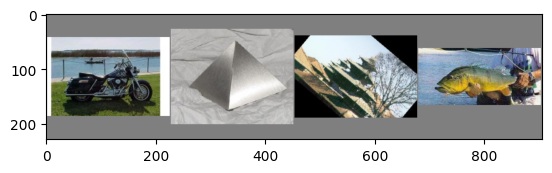

GroundTruth:
 Motorbikes pyramid    pagoda     bass      


In [18]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print("GroundTruth:\n", " ".join(f"{classes[labels[j]]:10s}" for j in range(4)))

In [12]:
net = Net(nb_classes=len(classes))
net.load_state_dict(torch.load(model_path, weights_only=True))
net.to(device)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(5, 5))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=101, bias=True)
)

In [13]:
outputs = net(images.to(device))
_, predicted = torch.max(outputs, 1)

print("Predicted: ", " ".join(f"{classes[predicted[j]]:5s}" for j in range(4)))

Predicted:  Motorbikes scorpion pagoda ferry


In [14]:

# Call the function
accuracy, precision, recall, f1score = evaluate_model(net, test_loader, device)

Accuracy of the network on the 1736 test images: 49.48%
Weighted Precision: 0.5297
Weighted Recall: 0.4948
Weighted F1-score: 0.4844


/home/ezalos/42/Notebooks2Teach/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
